In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Part 1

In [ ]:
!uv pip install ultralytics roboflow opencv-python 

import matplotlib.pyplot as plt
import numpy as np
import torch
from ultralytics import YOLO 
from roboflow import Roboflow
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
rf_apikey = user_secrets.get_secret("roboflow_universe")
rf_apikey[:4]

rf = Roboflow(api_key=rf_apikey)
project = rf.workspace("gfo-fc1de").project("fire-and-smoke-detector-yykya")
version = project.version(14)
dataset = version.download("yolo26")



Part 2

In [21]:
# I downloaded the yaml and just put the details
print('Workspace URL: https://universe.roboflow.com/gfo-fc1de')

print('Project: fire-and-smoke-detector-yykya')

print('Version: 14')

dataset_path = dataset.location
print(f"Path: {dataset_path}")

SELECTED WORKSPACE:
Workspace URL: https://universe.roboflow.com/gfo-fc1de
SELECTED PROJECT:
Project: fire-and-smoke-detector-yykya
DATASET VERSION:
Version: 14
DATASET LOCATION:
Path: /kaggle/working/fire-and-smoke-detector-14


Part 3

In [4]:
model = YOLO('yolo26n.pt')

results = model.train(data=f'{dataset.location}/data.yaml', epochs=50, imgsz=640,
                     resume=True)

WARNING ⚠️ model 'yolo26n.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/fire-and-smoke-detector-14/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0

1. Detection in YOLO means to find where the object is located in the image it can show the object by a square/rectangle or the shape of the actual object itself
2. We use small YOLO models first to identify objects and not use too much processing power
3. An epoch is like one training cycle throught all the dataset if it is 50 like we did that means we trained around 10k images 50 times!
4. Image size is the resolution in our question we used 640x640 but if we keep increasing the number of pixels picture becomes much clearer however it will need more processing power to detect objects
5. The model scans the image and detects the object then it identifies which class it is, then it checks from the training dataset whether it is right or wrong and then depending on the number epochs it learns from its mistakes and model improves

Part 4

In [ ]:
best_model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
last_model = YOLO('/kaggle/working/runs/detect/train/weights/last.pt')
train_results = YOLO('/kaggle/working/runs/detect/train/results.png')
valid_results = YOLO('/kaggle/working/runs/detect/train/results.png')
confusion_matrix = YOLO('/kaggle/working/runs/detect/train/confusion_matrix.png')

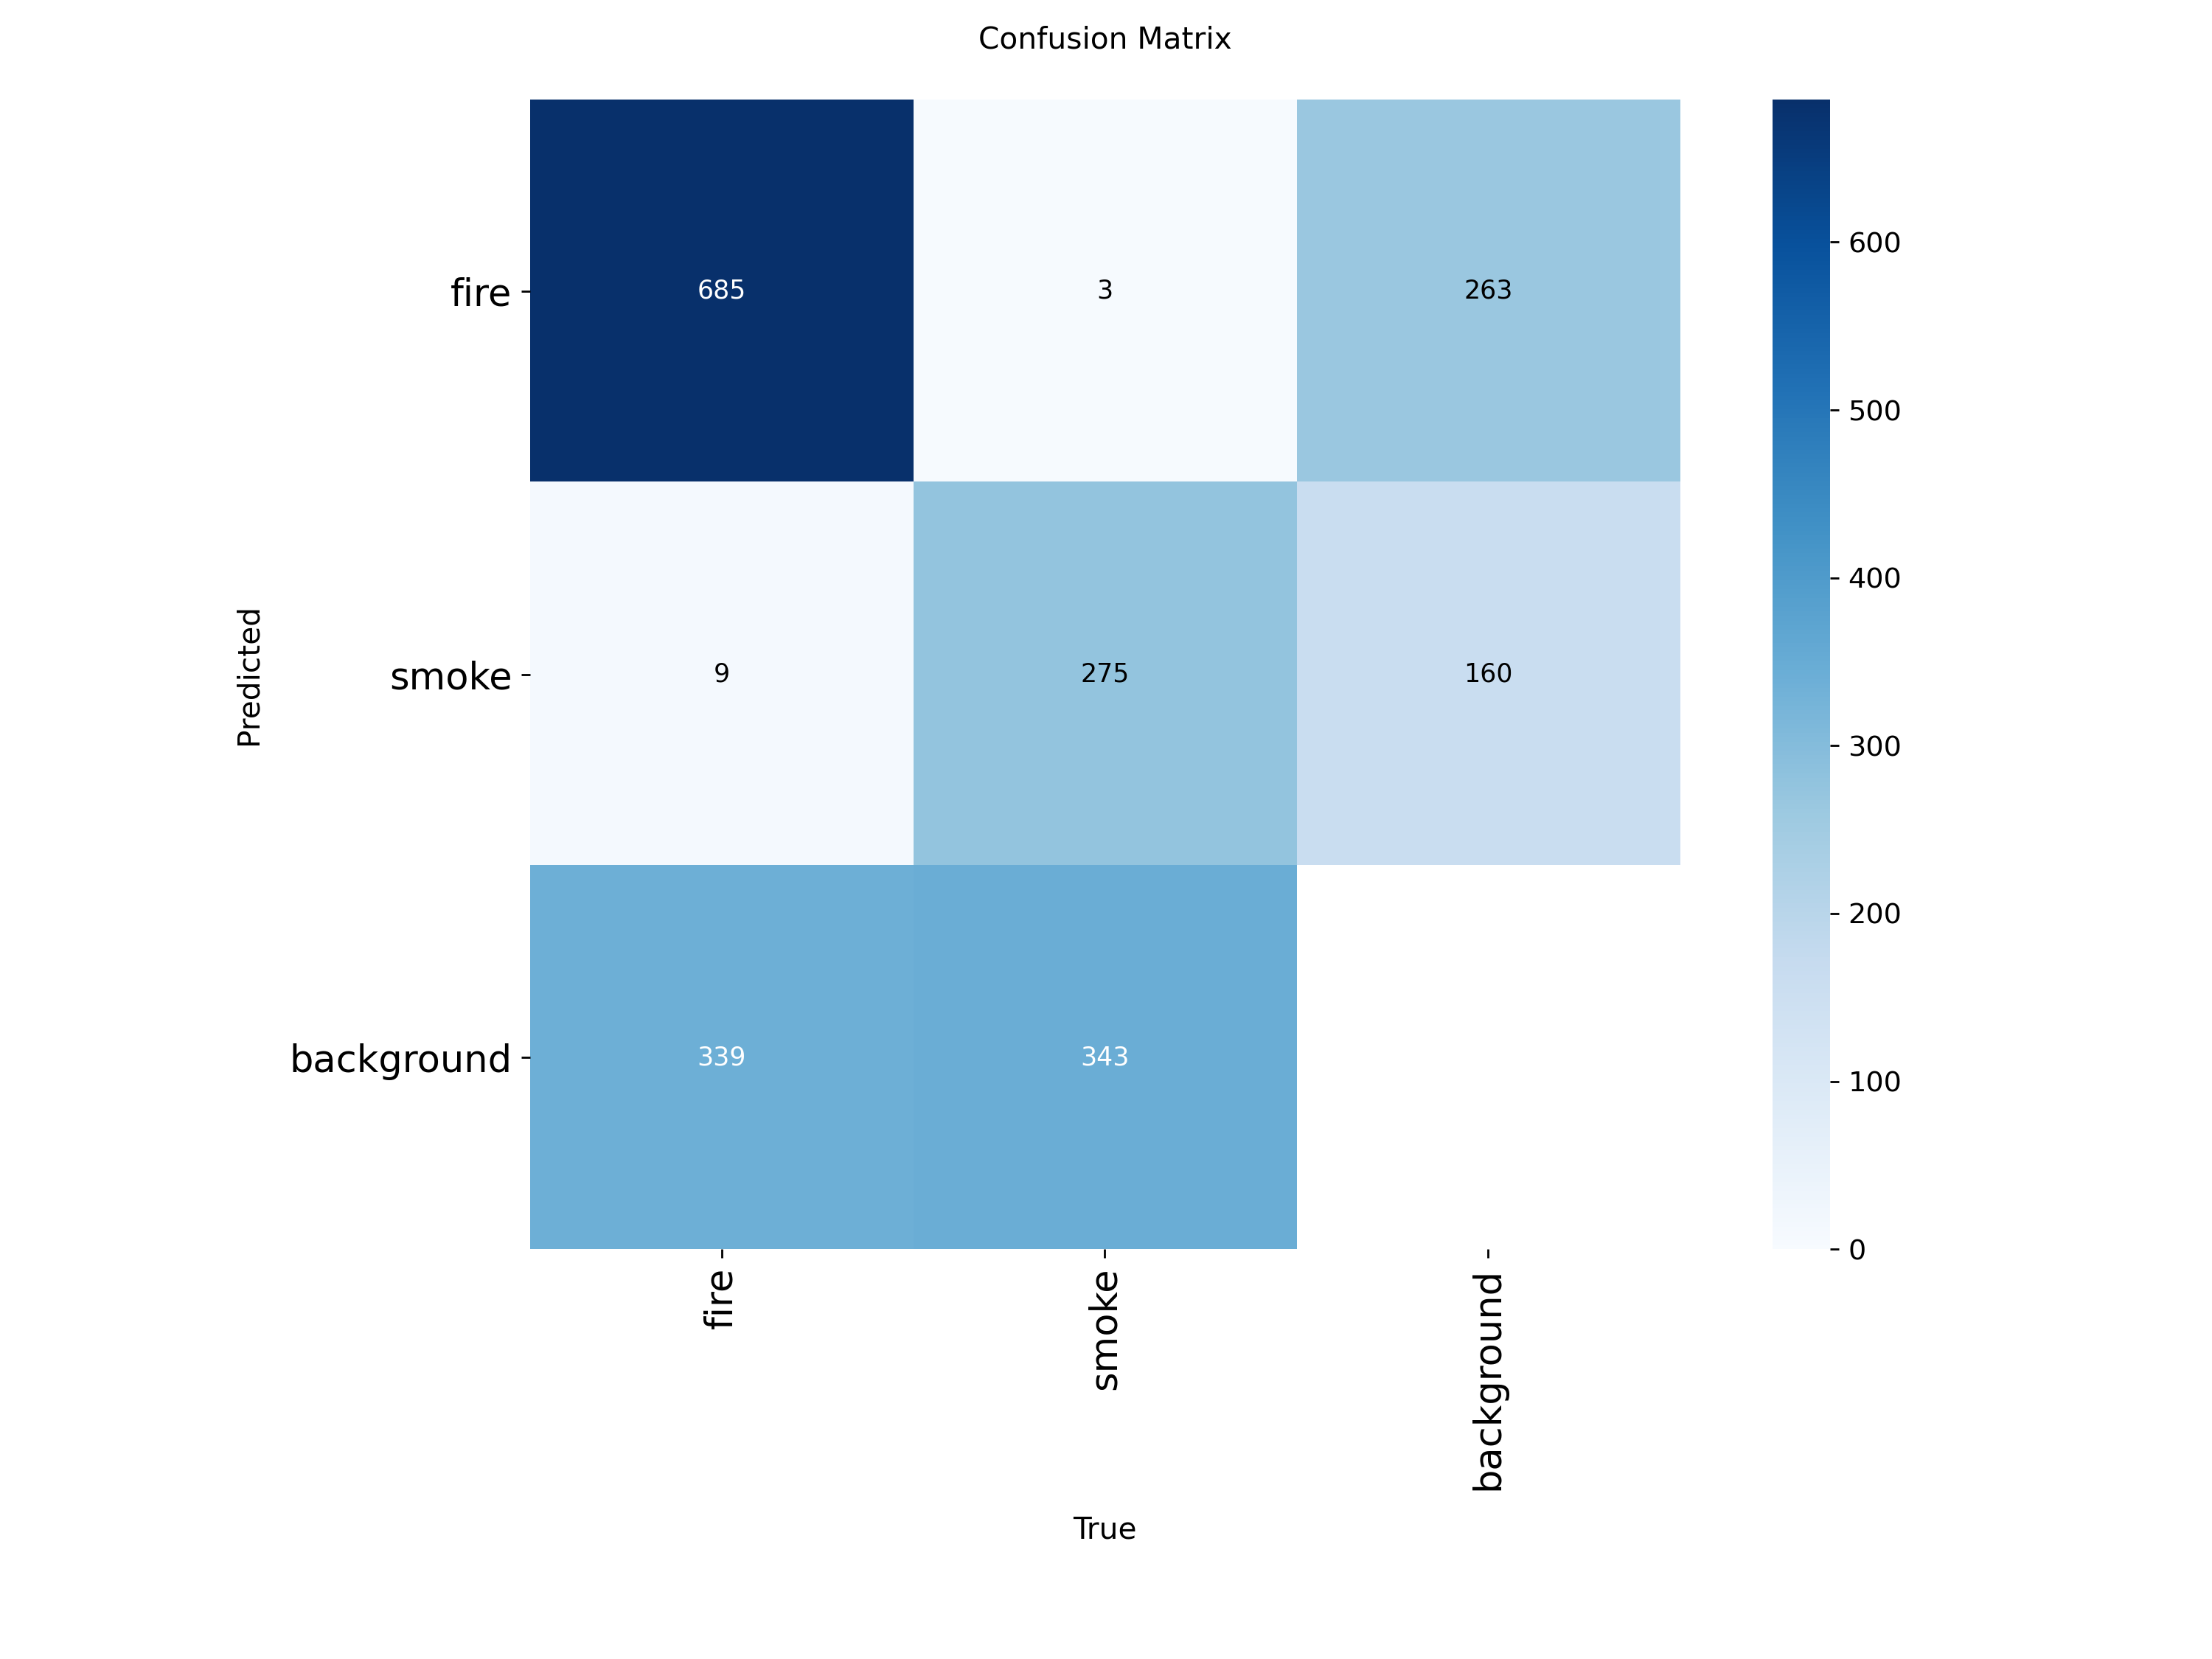

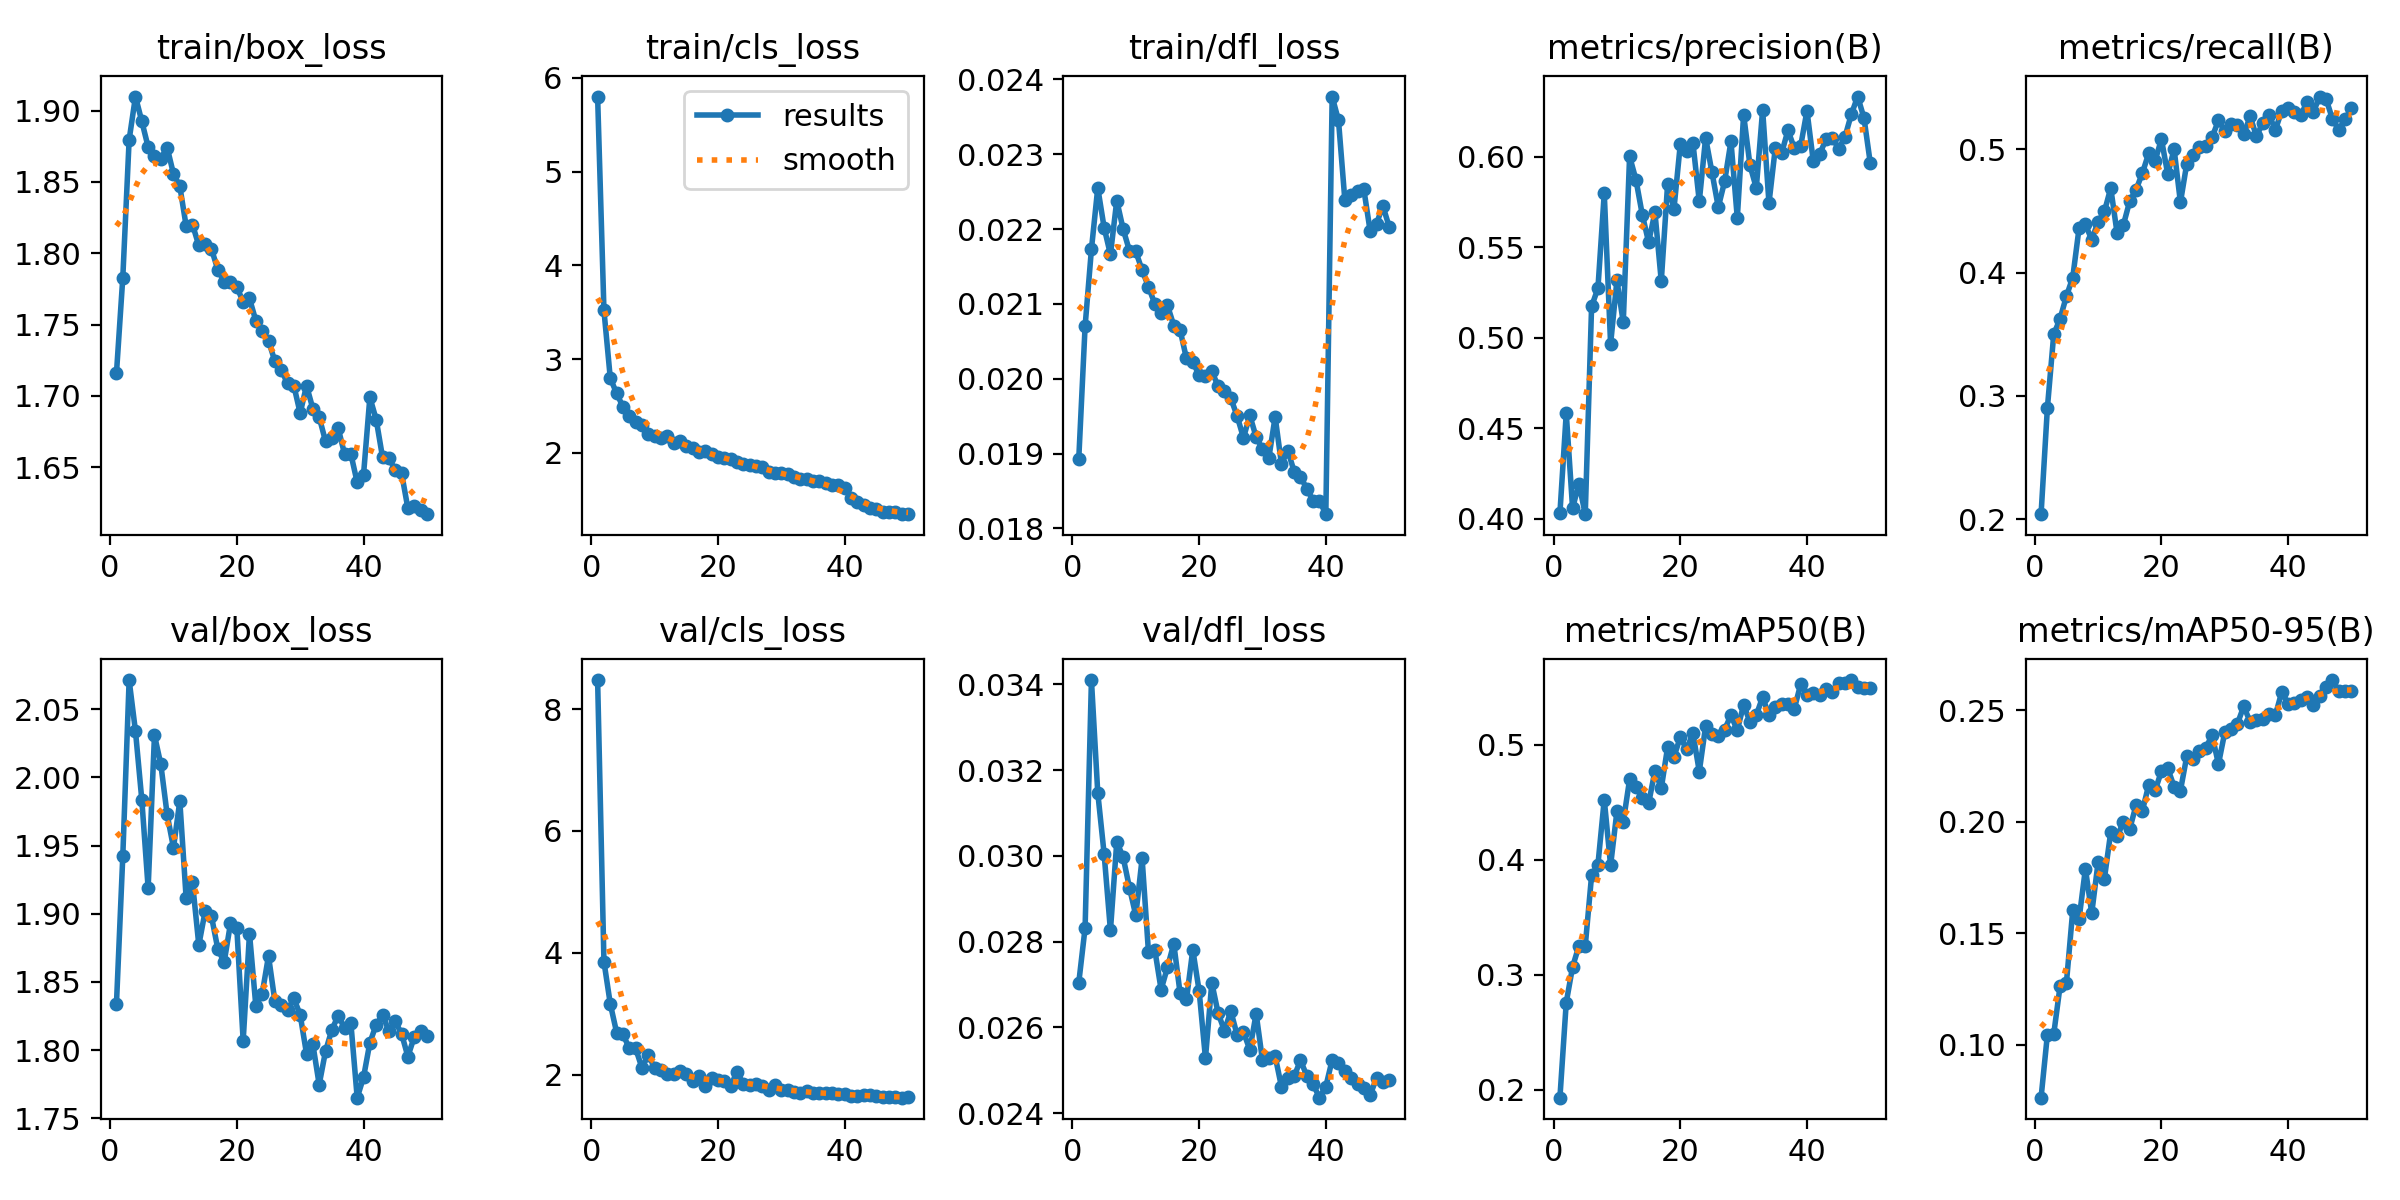

1. The best.pt is the best accurate model after training and last.pt is the last model trained
2. It means results are exact and have a high precision if everything is almost the same
3. Recall measures how many of the actual objects the model successfully found
4. it is mean average precision its the overall grade for the model and combines both precision and recall 

Part 5

In [23]:
smoke_vid = "/kaggle/input/datasets/edx409ahmedwael/smoke-vid/smoke video.mp4"
best_model.predict(
    source=smoke_vid
    ,save=True, conf=0.2
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/300) /kaggle/input/datasets/edx409ahmedwael/smoke-vid/smoke video.mp4: 384x640 (no detections), 12.6ms
video 1/1 (frame 2/300) /kaggle/input/datasets/edx409ahmedwael/smoke-vid/smoke video.mp4: 384x640 (no detections), 11.3ms
video 1/1 (frame 3/300) /kaggle/input/datasets/edx409ahmedwael/smoke-vid/smoke video.mp4: 384x640 (no detections), 10.4ms
video 1/1 (frame 4/300) /kaggle/input/datasets/edx409ahmedwael/smoke-vid/smoke video.mp4: 38

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'fire', 1: 'smoke'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 

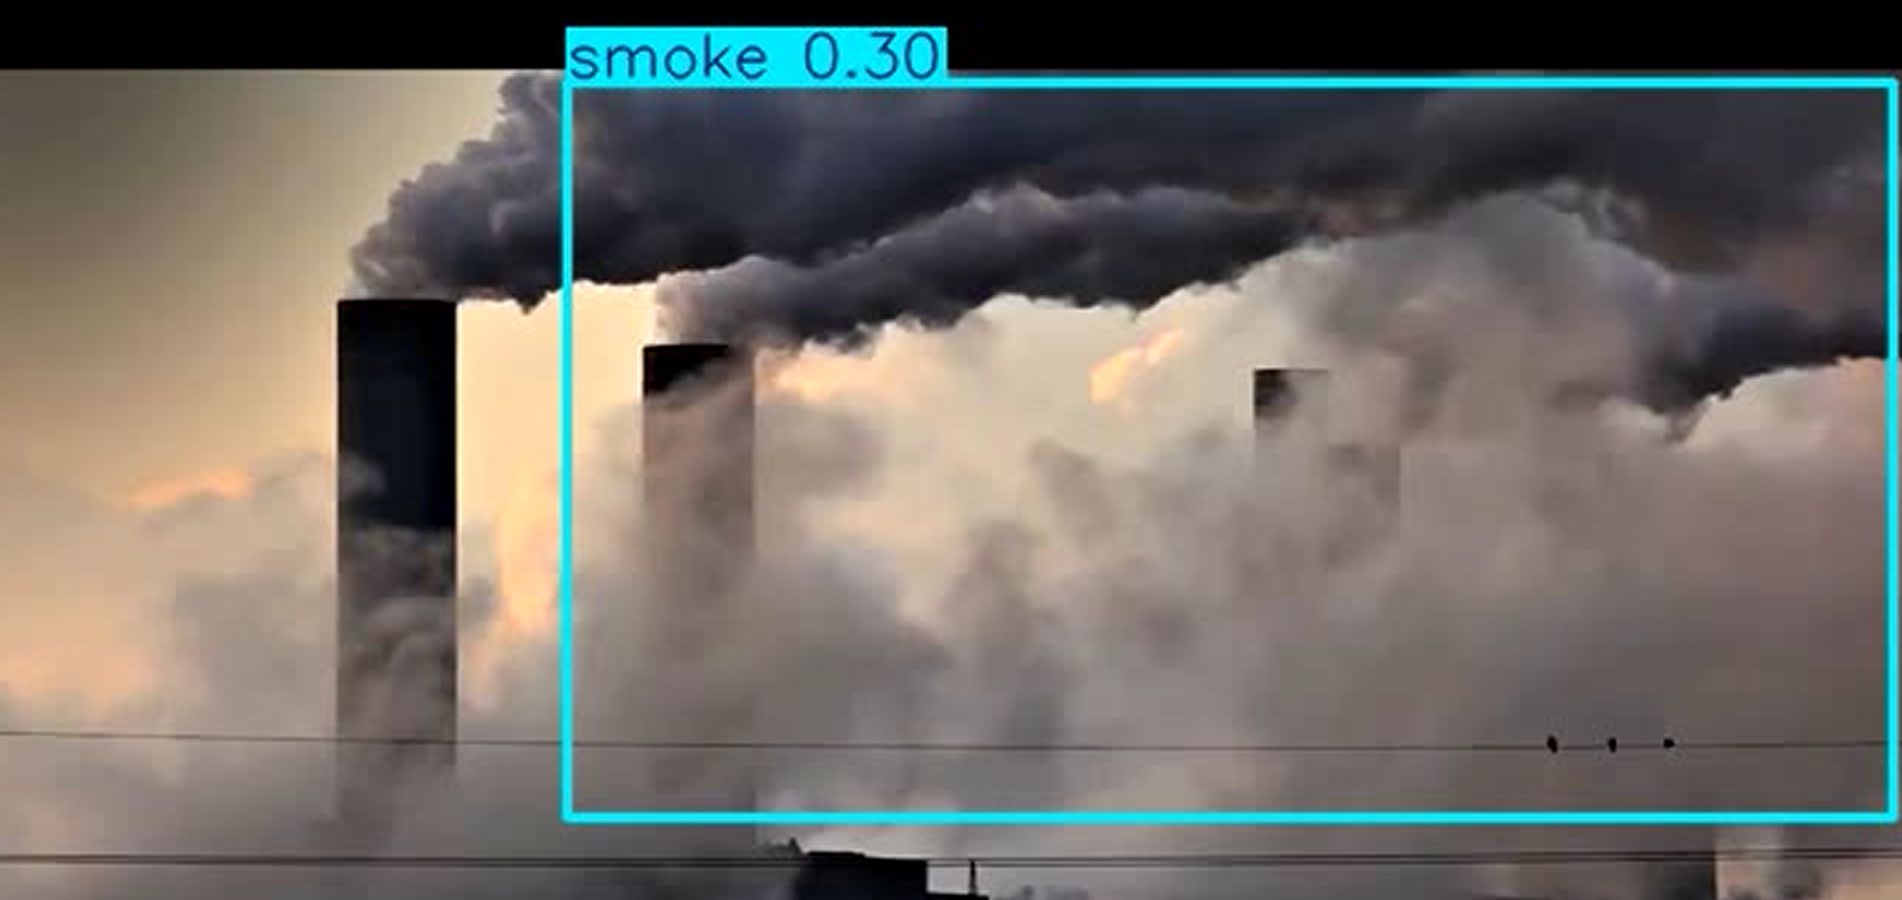

1. Interference is when model is trained on unseen data
2. it divides images into grids then predicts box coordinates and then draws the box
3. it helps us see predicitions that are in general more reliable than a probability of less than 0.2 for example